In [1]:
!pip install tensorflow
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.7 MB/s eta 0:00:00


In [2]:
import os
import numpy as np

# 1. Khai báo và tạo thư mục 'data' nằm ngay trong thư mục project hiện tại
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)

# =========================================================
# 2. TẢI DIGIT MNIST VÀ FASHION MNIST
# =========================================================
# MẸO: Ép thư viện Keras đổi "nhà" từ ổ đĩa hệ thống sang thư mục project của bạn
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import mnist, fashion_mnist

print("Đang tải Digit MNIST vào project...")
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

print("Đang tải Fashion MNIST vào project...")
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()
# Keras sẽ tự động tạo một thư mục con tên là 'datasets' bên trong thư mục 'data' của bạn.
# Các file tải về sẽ nằm ở: ./data/datasets/


# =========================================================
# 3. TẢI PNEUMONIA MNIST (MEDICAL)
# =========================================================
import medmnist
from medmnist import PneumoniaMNIST

print("Đang tải Pneumonia MNIST vào project...")
# Với MedMNIST, chỉ cần truyền biến root là xong
train_pneumonia = PneumoniaMNIST(split='train', download=True, root=PROJECT_DATA_DIR)
test_pneumonia  = PneumoniaMNIST(split='test',  download=True, root=PROJECT_DATA_DIR)

# Trích xuất ra ma trận Numpy
X_train_pneumonia = train_pneumonia.imgs
y_train_pneumonia = train_pneumonia.labels.squeeze()

X_test_pneumonia = test_pneumonia.imgs
y_test_pneumonia = test_pneumonia.labels.squeeze()

print("\n🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục:", PROJECT_DATA_DIR)

Đang tải Digit MNIST vào project...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đang tải Fashion MNIST vào project...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đang tải Pneumonia MNIST vào project...


100%|██████████| 4.17M/4.17M [00:06<00:00, 668kB/s]



🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục: ./data


In [3]:
def describe_raw(name, X, y):
    print(f"\n{name}")
    print(f"  X shape: {X.shape}, dtype: {X.dtype}")
    print(f"  y shape: {y.shape}, dtype: {y.dtype}")
    print(f"  X min/max: {X.min()} / {X.max()}")
    print(f"  Unique labels: {np.unique(y)}")

describe_raw("Digit MNIST (raw)", X_train_digit, y_train_digit)
describe_raw("Fashion MNIST (raw)", X_train_fashion, y_train_fashion)
describe_raw("Pneumonia MNIST (raw)", X_train_pneumonia, y_train_pneumonia)


Digit MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Fashion MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Pneumonia MNIST (raw)
  X shape: (4708, 28, 28), dtype: uint8
  y shape: (4708,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1]


In [4]:
X_train_digit[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class baseline_ANN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(baseline_ANN, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x

# Training digit set with baseline

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [30]:
def train_baseline(model, X_train, y_train, criterion=nn.CrossEntropyLoss(), epochs=100, lr = 0.001):
  """
    X_train, y_train: torch.tensor
    X_train.shape = (N, 28, 28): -> this will be flatten
  """
  print("training")
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  inputs = torch.flatten(X_train, start_dim=1).to(device) # Move inputs to device
  labels = y_train.to(device) # Move labels to device

  for epoch in range(epochs):
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
  return

# train_baseline(digit_model, X_train_digit_tensor, y_train_digit_tensor)

# Inference

In [31]:
def acc(model, input, label):
  model.eval()
  predict_outputs = model(torch.flatten(torch.tensor(input, dtype=torch.float32), start_dim=1).to(device) / 255.0)
  labels = torch.tensor(label).to(device)

  _, predicted = torch.max(predict_outputs, 1)
  correct = (labels == predicted).sum().item()
  total = len(labels)

  return correct/total

# acc(digit_model2, X_test_digit, y_test_digit)

In [32]:

class baseline_ANN_2_hidden_layer(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(baseline_ANN_2_hidden_layer, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, 128)
    self.fc3 = nn.Linear(128, output_size)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x

In [33]:
# setup
digit_model = baseline_ANN_2_hidden_layer(28 * 28, 256, 10)
criterion = nn.CrossEntropyLoss()
digit_model.to(device)

train_baseline(digit_model, torch.tensor(X_train_digit, dtype=torch.float32) / 255.0, torch.tensor(y_train_digit, dtype=torch.long))

training
Epoch [10/100], Loss: 1.6599
Epoch [20/100], Loss: 0.7400
Epoch [30/100], Loss: 0.4388
Epoch [40/100], Loss: 0.3508
Epoch [50/100], Loss: 0.3052
Epoch [60/100], Loss: 0.2749
Epoch [70/100], Loss: 0.2516
Epoch [80/100], Loss: 0.2316
Epoch [90/100], Loss: 0.2131
Epoch [100/100], Loss: 0.1955


In [34]:
# setup
fashion_model = baseline_ANN_2_hidden_layer(28 * 28, 256, 10)
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(fashion_model.parameters(), lr = 0.001)
fashion_model.to(device)

train_baseline(fashion_model, torch.tensor(X_train_fashion, dtype=torch.float32) / 255.0, torch.tensor(y_train_fashion, dtype=torch.long))

training
Epoch [10/100], Loss: 1.4810
Epoch [20/100], Loss: 0.8195
Epoch [30/100], Loss: 0.6681
Epoch [40/100], Loss: 0.5773
Epoch [50/100], Loss: 0.5240
Epoch [60/100], Loss: 0.4867
Epoch [70/100], Loss: 0.4583
Epoch [80/100], Loss: 0.4370
Epoch [90/100], Loss: 0.4239
Epoch [100/100], Loss: 0.4070


In [36]:
# setup
pneumonia_model = baseline_ANN_2_hidden_layer(28 * 28, 256, 2)
criterion = nn.BCELoss()
# optimizer = torch.optim.Adam(fashion_model.parameters(), lr = 0.001)
pneumonia_model.to(device)

train_baseline(pneumonia_model, torch.tensor(X_train_pneumonia, dtype=torch.float32) / 255.0, torch.tensor(y_train_pneumonia, dtype=torch.long))

training
Epoch [10/100], Loss: 0.5396
Epoch [20/100], Loss: 0.4678
Epoch [30/100], Loss: 0.3113
Epoch [40/100], Loss: 0.2110
Epoch [50/100], Loss: 0.1779
Epoch [60/100], Loss: 0.1534
Epoch [70/100], Loss: 0.1437
Epoch [80/100], Loss: 0.1313
Epoch [90/100], Loss: 0.1269
Epoch [100/100], Loss: 0.1228


In [37]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_metrics(model, X_test, y_test, num_classes):
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    # Prepare test data and move to device
    inputs = torch.flatten(torch.tensor(X_test, dtype=torch.float32), start_dim=1).to(device) / 255.0
    labels = torch.tensor(y_test).to(device)

    # Get predictions
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    # Move predictions and labels back to CPU for scikit-learn metrics
    predicted_cpu = predicted.cpu().numpy()
    labels_cpu = labels.cpu().numpy()

    # Calculate metrics
    accuracy = (labels_cpu == predicted_cpu).sum() / len(labels_cpu)
    f1 = f1_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    precision = precision_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    recall = recall_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    cm = confusion_matrix(labels_cpu, predicted_cpu)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, f1, precision, recall, cm

### Evaluating Digit MNIST Model

Metrics for Digit MNIST Model:
Accuracy: 0.9438
F1 Score: 0.9437
Precision: 0.9437
Recall: 0.9438


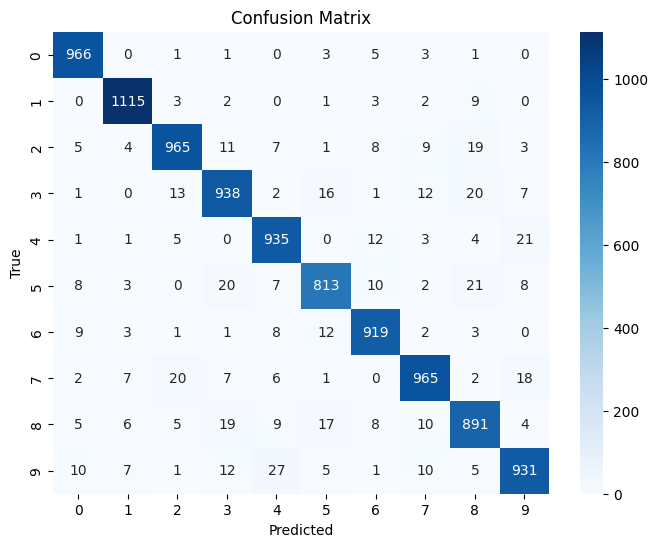

In [38]:
print("Metrics for Digit MNIST Model:")
digit_metrics = evaluate_model_metrics(digit_model, X_test_digit, y_test_digit, num_classes=10)

### Evaluating Fashion MNIST Model

Metrics for Fashion MNIST Model:
Accuracy: 0.8443
F1 Score: 0.8425
Precision: 0.8429
Recall: 0.8443


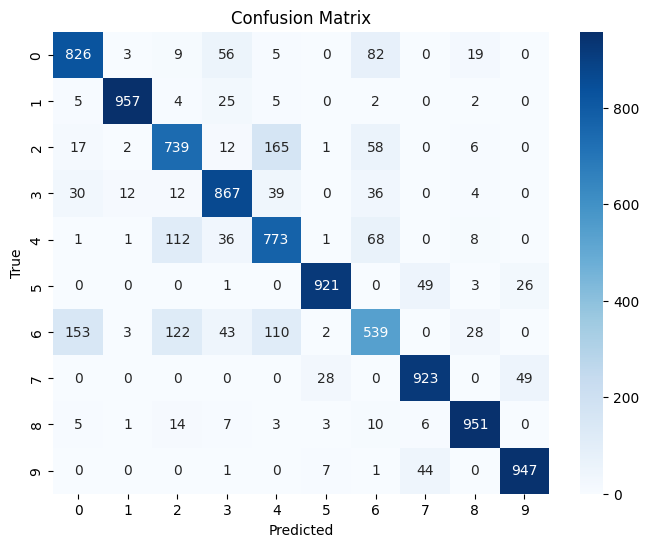

In [39]:
print("Metrics for Fashion MNIST Model:")
fashion_metrics = evaluate_model_metrics(fashion_model, X_test_fashion, y_test_fashion, num_classes=10)

### Evaluating Pneumonia MNIST Model

Metrics for Pneumonia MNIST Model:
Accuracy: 0.8349
F1 Score: 0.8817
Precision: 0.7983
Recall: 0.9846


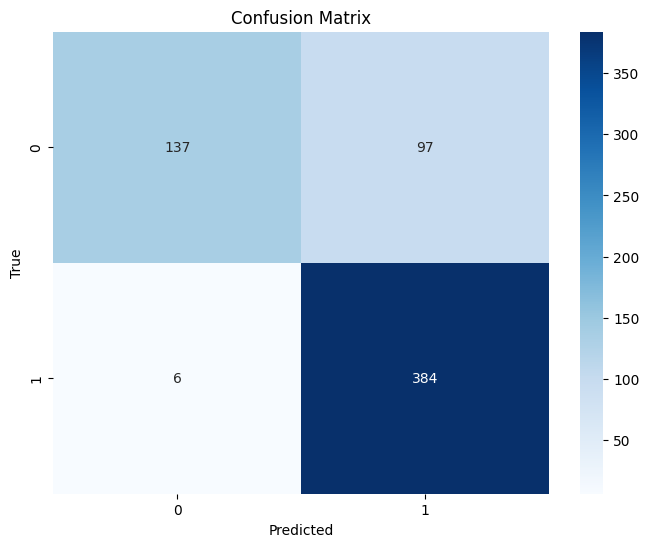

In [40]:
print("Metrics for Pneumonia MNIST Model:")
pneumonia_metrics = evaluate_model_metrics(pneumonia_model, X_test_pneumonia, y_test_pneumonia, num_classes=2)